In [ ]:
from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score,
    roc_curve,
    make_scorer
)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, silhouette_score

import warnings
warnings.filterwarnings("ignore")

In [2]:
DATASET_PATH = Path("../dataset/fraud.csv")

if not DATASET_PATH.exists():
    raise FileNotFoundError(
        "Dataset not found. Place the full fraud dataset at ml/dataset/fraud.csv "
        "before running this notebook. The file is intentionally not committed because of its size."
    )

df = pd.read_csv(DATASET_PATH)

df = df.sample(n=50000, random_state=42)

df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
3737323,278,CASH_IN,330218.42,C632336343,20866.00,351084.42,C834976624,452419.57,122201.15,0,0
264914,15,PAYMENT,11647.08,C1264712553,30370.00,18722.92,M215391829,0.00,0.00,0,0
85647,10,CASH_IN,152264.21,C1746846248,106589.00,258853.21,C1607284477,201303.01,49038.80,0,0
5899326,403,TRANSFER,1551760.63,C333676753,0.00,0.00,C1564353608,3198359.45,4750120.08,0,0
2544263,206,CASH_IN,78172.30,C813403091,2921331.58,2999503.88,C1091768874,415821.90,337649.60,0,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
Index: 50000 entries, 3737323 to 409882
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   step            50000 non-null  int64  
 1   type            50000 non-null  str    
 2   amount          50000 non-null  float64
 3   nameOrig        50000 non-null  str    
 4   oldbalanceOrg   50000 non-null  float64
 5   newbalanceOrig  50000 non-null  float64
 6   nameDest        50000 non-null  str    
 7   oldbalanceDest  50000 non-null  float64
 8   newbalanceDest  50000 non-null  float64
 9   isFraud         50000 non-null  int64  
 10  isFlaggedFraud  50000 non-null  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 4.6 MB


In [4]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,50000.000000,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,50000.000000,50000.000000
mean,243.524580,1.802593e+05,8.405440e+05,8.623184e+05,1.092142e+06,1.217457e+06,0.001400,0.000020
std,142.989564,5.394901e+05,2.905490e+06,2.940672e+06,3.123411e+06,3.349252e+06,0.037391,0.004472
min,1.000000,9.200000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000
25%,155.000000,1.358008e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000
50%,239.000000,7.568036e+04,1.384450e+04,0.000000e+00,1.432386e+05,2.210873e+05,0.000000,0.000000
75%,335.000000,2.092434e+05,1.070732e+05,1.471921e+05,9.639589e+05,1.129805e+06,0.000000,0.000000
max,736.000000,3.697390e+07,3.359321e+07,3.374855e+07,1.540135e+08,1.542411e+08,1.000000,1.000000


In [5]:
df["isFraud"].value_counts()

isFraud
0    49930
1       70
Name: count, dtype: int64

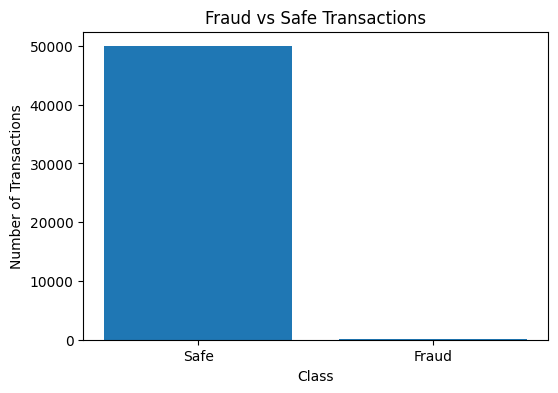

In [6]:
fraud_counts = df["isFraud"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(["Safe", "Fraud"], fraud_counts.values)
plt.title("Fraud vs Safe Transactions")
plt.xlabel("Class")
plt.ylabel("Number of Transactions")
plt.show()

In [7]:
selected_columns = [
    "type",
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "isFraud"
]

df = df[selected_columns]

df.head()

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
3737323,CASH_IN,330218.42,20866.00,351084.42,452419.57,122201.15,0
264914,PAYMENT,11647.08,30370.00,18722.92,0.00,0.00,0
85647,CASH_IN,152264.21,106589.00,258853.21,201303.01,49038.80,0
5899326,TRANSFER,1551760.63,0.00,0.00,3198359.45,4750120.08,0
2544263,CASH_IN,78172.30,2921331.58,2999503.88,415821.90,337649.60,0


In [8]:
df.isnull().sum()

type              0
amount            0
oldbalanceOrg     0
newbalanceOrig    0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
dtype: int64

In [9]:
df_encoded = pd.get_dummies(df, columns=["type"], drop_first=False)

df_encoded.head()

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
3737323,330218.42,20866.00,351084.42,452419.57,122201.15,0,True,False,False,False,False
264914,11647.08,30370.00,18722.92,0.00,0.00,0,False,False,False,True,False
85647,152264.21,106589.00,258853.21,201303.01,49038.80,0,True,False,False,False,False
5899326,1551760.63,0.00,0.00,3198359.45,4750120.08,0,False,False,False,False,True
2544263,78172.30,2921331.58,2999503.88,415821.90,337649.60,0,True,False,False,False,False


In [10]:
X = df_encoded.drop("isFraud", axis=1)
y = df_encoded["isFraud"]

X.head()

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
3737323,330218.42,20866.00,351084.42,452419.57,122201.15,True,False,False,False,False
264914,11647.08,30370.00,18722.92,0.00,0.00,False,False,False,True,False
85647,152264.21,106589.00,258853.21,201303.01,49038.80,True,False,False,False,False
5899326,1551760.63,0.00,0.00,3198359.45,4750120.08,False,False,False,False,True
2544263,78172.30,2921331.58,2999503.88,415821.90,337649.60,True,False,False,False,False


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (40000, 10)
Testing size: (10000, 10)


In [12]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
confusion_matrices = {}


def evaluate_model(model_name, model, X_test_data, y_test_data):
    y_pred = model.predict(X_test_data)
    
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test_data)[:, 1]
        roc_auc = roc_auc_score(y_test_data, y_proba)
    else:
        roc_auc = None
    
    accuracy = accuracy_score(y_test_data, y_pred)
    precision = precision_score(y_test_data, y_pred, zero_division=0)
    recall = recall_score(y_test_data, y_pred, zero_division=0)
    f1 = f1_score(y_test_data, y_pred, zero_division=0)
    cm = confusion_matrix(y_test_data, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    confusion_matrices[model_name] = cm
    
    print("Model:", model_name)
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1-score:", f1)
    print("ROC-AUC:", roc_auc)
    print("\nConfusion Matrix:")
    print(cm)
    print("\nClassification Report:")
    print(classification_report(y_test_data, y_pred, zero_division=0))
    
    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "ROC-AUC": roc_auc,
        "True Negatives": tn,
        "False Positives": fp,
        "False Negatives": fn,
        "True Positives": tp,
    }


## Hyperparameter tuning setup

The following classifiers are tuned with `GridSearchCV` using 3-fold cross-validation and F1-score as the optimization metric. F1-score is used because the dataset is highly imbalanced and fraud detection needs a balance between precision and recall.

### Tested grids and selected values

| Classifier | Tested hyperparameter grid | Final selected values |
|---|---|---|
| Logistic Regression | `C: [0.1, 1, 10]`; `solver: ["liblinear"]` | `C=10`; `solver="liblinear"` |
| KNN | `n_neighbors: [3, 5, 7]`; `weights: ["uniform", "distance"]` | `n_neighbors=3`; `weights="distance"` |
| Decision Tree | `max_depth: [5, 10, 15, None]`; `min_samples_split: [2, 5, 10]`; `criterion: ["gini", "entropy"]` | `max_depth=15`; `min_samples_split=2`; `criterion="entropy"` |
| Random Forest | `n_estimators: [50, 100]`; `max_depth: [10, 20, None]`; `min_samples_split: [2, 5]` | `n_estimators=100`; `max_depth=20`; `min_samples_split=5` |
| Neural Network (MLP) | `hidden_layer_sizes: [(32,), (64,), (64, 32)]`; `activation: ["relu", "tanh"]`; `learning_rate_init: [0.001, 0.01]` | `hidden_layer_sizes=(32,)`; `activation="tanh"`; `learning_rate_init=0.01` |

### Best-parameter summary

| Model | Best parameters |
|---|---|
| Logistic Regression | `{"C": 10, "solver": "liblinear"}` |
| KNN | `{"n_neighbors": 3, "weights": "distance"}` |
| Decision Tree | `{"criterion": "entropy", "max_depth": 15, "min_samples_split": 2}` |
| Random Forest | `{"max_depth": 20, "min_samples_split": 5, "n_estimators": 100}` |
| Neural Network (MLP) | `{"activation": "tanh", "hidden_layer_sizes": (32,), "learning_rate_init": 0.01}` |


In [14]:
log_reg_params = {
    "C": [0.1, 1, 10],
    "solver": ["liblinear"]
}

log_reg_grid = GridSearchCV(
    LogisticRegression(max_iter=1000, class_weight="balanced"),
    log_reg_params,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

log_reg_grid.fit(X_train_scaled, y_train)

best_log_reg = log_reg_grid.best_estimator_

print("Best Logistic Regression parameters:")
print(log_reg_grid.best_params_)

Best Logistic Regression parameters:
{'C': 10, 'solver': 'liblinear'}


In [15]:
results = []

results.append(
    evaluate_model(
        "Logistic Regression",
        best_log_reg,
        X_test_scaled,
        y_test
    )
)

Model: Logistic Regression
Accuracy: 0.9467
Precision: 0.023853211009174313
Recall: 0.9285714285714286
F1-score: 0.046511627906976744
ROC-AUC: 0.9245372092357873

Confusion Matrix:
[[9454  532]
 [   1   13]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.97      9986
           1       0.02      0.93      0.05        14

    accuracy                           0.95     10000
   macro avg       0.51      0.94      0.51     10000
weighted avg       1.00      0.95      0.97     10000



In [16]:
knn_params = {
    "n_neighbors": [3, 5, 7],
    "weights": ["uniform", "distance"]
}

knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    knn_params,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

knn_grid.fit(X_train_scaled, y_train)

best_knn = knn_grid.best_estimator_

print("Best KNN parameters:")
print(knn_grid.best_params_)

Best KNN parameters:
{'n_neighbors': 3, 'weights': 'distance'}


In [17]:
results.append(
    evaluate_model(
        "KNN",
        best_knn,
        X_test_scaled,
        y_test
    )
)

Model: KNN
Accuracy: 0.9994
Precision: 0.9
Recall: 0.6428571428571429
F1-score: 0.75
ROC-AUC: 0.8569497296214702

Confusion Matrix:
[[9985    1]
 [   5    9]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9986
           1       0.90      0.64      0.75        14

    accuracy                           1.00     10000
   macro avg       0.95      0.82      0.87     10000
weighted avg       1.00      1.00      1.00     10000



In [18]:
tree_params = {
    "max_depth": [5, 10, 15, None],
    "min_samples_split": [2, 5, 10],
    "criterion": ["gini", "entropy"]
}

tree_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42, class_weight="balanced"),
    tree_params,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

tree_grid.fit(X_train, y_train)

best_tree = tree_grid.best_estimator_

print("Best Decision Tree parameters:")
print(tree_grid.best_params_)

Best Decision Tree parameters:
{'criterion': 'entropy', 'max_depth': 15, 'min_samples_split': 2}


In [19]:
results.append(
    evaluate_model(
        "Decision Tree",
        best_tree,
        X_test,
        y_test
    )
)

Model: Decision Tree
Accuracy: 0.9993
Precision: 0.7692307692307693
Recall: 0.7142857142857143
F1-score: 0.7407407407407407
ROC-AUC: 0.856992646848445

Confusion Matrix:
[[9983    3]
 [   4   10]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9986
           1       0.77      0.71      0.74        14

    accuracy                           1.00     10000
   macro avg       0.88      0.86      0.87     10000
weighted avg       1.00      1.00      1.00     10000



In [20]:
rf_params = {
    "n_estimators": [50, 100],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight="balanced"),
    rf_params,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_

print("Best Random Forest parameters:")
print(rf_grid.best_params_)

Best Random Forest parameters:
{'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 100}


In [21]:
results.append(
    evaluate_model(
        "Random Forest",
        best_rf,
        X_test,
        y_test
    )
)

Model: Random Forest
Accuracy: 0.9997
Precision: 1.0
Recall: 0.7857142857142857
F1-score: 0.88
ROC-AUC: 0.9269548796887072

Confusion Matrix:
[[9986    0]
 [   3   11]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9986
           1       1.00      0.79      0.88        14

    accuracy                           1.00     10000
   macro avg       1.00      0.89      0.94     10000
weighted avg       1.00      1.00      1.00     10000



In [22]:
mlp_params = {
    "hidden_layer_sizes": [
        (32,),
        (64,),
        (64, 32)
    ],
    "activation": ["relu", "tanh"],
    "learning_rate_init": [0.001, 0.01]
}

mlp_grid = GridSearchCV(
    MLPClassifier(max_iter=300, random_state=42),
    mlp_params,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

mlp_grid.fit(X_train_scaled, y_train)

best_mlp = mlp_grid.best_estimator_

print("Best Neural Network parameters:")
print(mlp_grid.best_params_)

Best Neural Network parameters:
{'activation': 'tanh', 'hidden_layer_sizes': (32,), 'learning_rate_init': 0.01}


In [23]:
results.append(
    evaluate_model(
        "Neural Network MLP",
        best_mlp,
        X_test_scaled,
        y_test
    )
)

Model: Neural Network MLP
Accuracy: 0.9996
Precision: 1.0
Recall: 0.7142857142857143
F1-score: 0.8333333333333334
ROC-AUC: 0.9720394266258476

Confusion Matrix:
[[9986    0]
 [   4   10]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9986
           1       1.00      0.71      0.83        14

    accuracy                           1.00     10000
   macro avg       1.00      0.86      0.92     10000
weighted avg       1.00      1.00      1.00     10000



In [24]:
results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.9467,0.023853,0.928571,0.046512,0.924537
1,KNN,0.9994,0.900000,0.642857,0.750000,0.856950
2,Decision Tree,0.9993,0.769231,0.714286,0.740741,0.856993
3,Random Forest,0.9997,1.000000,0.785714,0.880000,0.926955
4,Neural Network MLP,0.9996,1.000000,0.714286,0.833333,0.972039


## Confusion matrix comparison

The confusion matrix shows how each classifier separates legitimate and fraudulent transactions. In this binary classification task, false positives are legitimate transactions incorrectly flagged as fraud, while false negatives are fraudulent transactions missed by the model. False negatives are especially important because they represent fraud that would pass through the system.

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()

for ax, (model_name, cm) in zip(axes, confusion_matrices.items()):
    display = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Not Fraud", "Fraud"],
    )
    display.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
    ax.set_title(model_name)

for ax in axes[len(confusion_matrices):]:
    ax.axis("off")

plt.suptitle("Confusion Matrix Comparison by Classifier", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
confusion_interpretation = []

for model_name, cm in confusion_matrices.items():
    tn, fp, fn, tp = cm.ravel()
    confusion_interpretation.append({
        "Model": model_name,
        "False Positives": fp,
        "False Negatives": fn,
        "Interpretation": (
            f"{fp} legitimate transactions were incorrectly flagged as fraud; "
            f"{fn} fraudulent transactions were missed."
        ),
    })

pd.DataFrame(confusion_interpretation)

### Confusion matrix interpretation

Using the recorded notebook run:

| Model | False positives | False negatives | Interpretation |
|---|---:|---:|---|
| Logistic Regression | 532 | 1 | Catches almost every fraud case, but incorrectly flags many legitimate transactions. This explains the high recall and very low precision. |
| KNN | 1 | 5 | Keeps false alerts low, but misses five fraud cases, so recall is lower than Logistic Regression. |
| Decision Tree | 3 | 4 | Produces a small number of false alerts and misses four fraud cases, giving balanced but weaker performance than Random Forest. |
| Random Forest | 0 | 3 | Produces no false positives in the recorded run and misses only three fraud cases, giving the best F1-score among the main classifiers. |
| Neural Network MLP | 0 | 4 | Also avoids false positives, but misses one more fraud case than Random Forest in the main comparison. Its ROC-AUC remains strong, suggesting useful probability ranking. |

For fraud detection, false negatives are usually the more serious operational risk because they allow fraudulent transactions to pass through. False positives still matter because they can create unnecessary reviews or block legitimate customers.

## ROC curve analysis

ROC curves compare how well each classifier separates fraud from non-fraud across all possible probability thresholds. The true positive rate measures fraud detection sensitivity, while the false positive rate measures how often legitimate transactions are incorrectly flagged. A larger area under the curve (AUC) means the model ranks fraudulent transactions above legitimate transactions more effectively.

In [ ]:
roc_models = {
    "Logistic Regression": (best_log_reg, X_test_scaled),
    "KNN": (best_knn, X_test_scaled),
    "Decision Tree": (best_tree, X_test),
    "Random Forest": (best_rf, X_test),
    "Neural Network MLP": (best_mlp, X_test_scaled),
}

roc_results = []

plt.figure(figsize=(10, 7))

for model_name, (model, X_test_data) in roc_models.items():
    y_proba = model.predict_proba(X_test_data)[:, 1]
    false_positive_rate, true_positive_rate, thresholds = roc_curve(y_test, y_proba)
    auc_score = roc_auc_score(y_test, y_proba)

    roc_results.append({
        "Model": model_name,
        "AUC": auc_score,
    })

    plt.plot(
        false_positive_rate,
        true_positive_rate,
        linewidth=2,
        label=f"{model_name} (AUC = {auc_score:.4f})",
    )

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random classifier")
plt.title("ROC Curves by Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

roc_results_df = pd.DataFrame(roc_results).sort_values(by="AUC", ascending=False)
roc_results_df

In [ ]:
plt.figure(figsize=(10, 5))
plt.bar(roc_results_df["Model"], roc_results_df["AUC"])
plt.title("AUC Score Comparison by Classifier")
plt.xlabel("Model")
plt.ylabel("ROC-AUC")
plt.ylim(0.0, 1.0)
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### ROC-AUC interpretation

Using the recorded notebook results, the Neural Network MLP has the strongest separation between fraud and non-fraud transactions with an ROC-AUC of `0.9720`. This indicates that its predicted probabilities rank fraudulent transactions above legitimate transactions most effectively across thresholds.

Random Forest (`0.9270`) and Logistic Regression (`0.9245`) are close behind by ROC-AUC, but they behave differently in the confusion matrix: Random Forest keeps false positives low, while Logistic Regression catches nearly all fraud but incorrectly flags many legitimate transactions. KNN (`0.8569`) and Decision Tree (`0.8570`) show weaker ranking performance.

For threshold-independent separation, Neural Network MLP is the strongest model. For practical fraud detection, ROC-AUC should still be interpreted together with precision, recall, F1-score, and false-positive/false-negative counts because the deployed decision threshold controls operational risk.

## K-fold cross-validation

A single train/test split can make model results depend on which rare fraud records happen to land in the test set. Stratified k-fold cross-validation gives a more stable estimate by training and validating each classifier across multiple folds while preserving the fraud/non-fraud class balance as much as possible.

The table below reports average accuracy, precision, recall, and F1-score across folds. Standard deviations are included to show model stability: smaller standard deviation means performance is more consistent across folds.

In [ ]:
cv_models = {
    "Logistic Regression": make_pipeline(StandardScaler(), best_log_reg),
    "KNN": make_pipeline(StandardScaler(), best_knn),
    "Decision Tree": best_tree,
    "Random Forest": best_rf,
    "Neural Network MLP": make_pipeline(StandardScaler(), best_mlp),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scoring = {
    "accuracy": make_scorer(accuracy_score),
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
}

cv_results = []

for model_name, model in cv_models.items():
    scores = cross_validate(
        estimator=model,
        X=X,
        y=y,
        cv=cv,
        scoring=cv_scoring,
        n_jobs=-1,
        return_train_score=False,
    )

    cv_results.append({
        "Model": model_name,
        "Accuracy Mean": scores["test_accuracy"].mean(),
        "Accuracy Std": scores["test_accuracy"].std(),
        "Precision Mean": scores["test_precision"].mean(),
        "Precision Std": scores["test_precision"].std(),
        "Recall Mean": scores["test_recall"].mean(),
        "Recall Std": scores["test_recall"].std(),
        "F1-score Mean": scores["test_f1"].mean(),
        "F1-score Std": scores["test_f1"].std(),
    })

cv_results_df = pd.DataFrame(cv_results).sort_values(
    by="F1-score Mean",
    ascending=False,
)

cv_results_df

In [ ]:
stability_summary = cv_results_df[[
    "Model",
    "Accuracy Std",
    "Precision Std",
    "Recall Std",
    "F1-score Std",
]].copy()

stability_summary["Overall Stability"] = stability_summary["F1-score Std"].apply(
    lambda value: "High" if value <= 0.05 else "Moderate" if value <= 0.15 else "Low"
)

stability_summary.sort_values(by="F1-score Std")

### Cross-validation stability discussion

Use the cross-validation comparison table to evaluate both average performance and fold-to-fold consistency:

- Models with high average F1-score and low F1-score standard deviation are the most stable choices because they perform well across different fraud/non-fraud splits.
- Logistic Regression may show stable recall but weak precision if it repeatedly flags many legitimate transactions as fraud across folds.
- KNN can be sensitive to the exact fraud examples in each fold because it depends on local neighborhoods in scaled feature space.
- Decision Tree can vary across folds because a single tree may learn split rules that fit fold-specific patterns.
- Random Forest should usually be more stable than Decision Tree because averaging many trees reduces variance.
- Neural Network MLP may vary more than tree ensembles if optimization converges differently or if minority-class fraud examples are sparse in each fold.

For this project, the preferred classifier should combine strong average F1-score with a small F1-score standard deviation. Accuracy standard deviation is less informative on its own because the dataset is highly imbalanced and legitimate transactions dominate every fold.

## Learning curve analysis

Learning curves show how model performance changes as the amount of training data increases. In this fraud detection task, the curves use F1-score because the dataset is highly imbalanced and F1-score balances precision and recall for the fraud class.

Interpretation guide:

- Underfitting: training and validation scores are both low and close together.
- Overfitting: training score is high, but validation score is much lower.
- Good generalization: training and validation scores are both strong and close together.

In [ ]:
learning_curve_models = {
    "Logistic Regression": (make_pipeline(StandardScaler(), best_log_reg), X, y),
    "KNN": (make_pipeline(StandardScaler(), best_knn), X, y),
    "Decision Tree": (best_tree, X, y),
    "Random Forest": (best_rf, X, y),
    "Neural Network MLP": (make_pipeline(StandardScaler(), best_mlp), X, y),
}

train_sizes = np.linspace(0.1, 1.0, 5)
learning_curve_results = {}

for model_name, (model, X_data, y_data) in learning_curve_models.items():
    sizes, train_scores, validation_scores = learning_curve(
        estimator=model,
        X=X_data,
        y=y_data,
        train_sizes=train_sizes,
        cv=3,
        scoring="f1",
        n_jobs=-1,
        shuffle=True,
        random_state=42,
    )

    learning_curve_results[model_name] = {
        "train_sizes": sizes,
        "train_mean": train_scores.mean(axis=1),
        "train_std": train_scores.std(axis=1),
        "validation_mean": validation_scores.mean(axis=1),
        "validation_std": validation_scores.std(axis=1),
    }

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey=True)
axes = axes.ravel()

for ax, (model_name, curve) in zip(axes, learning_curve_results.items()):
    sizes = curve["train_sizes"]
    train_mean = curve["train_mean"]
    train_std = curve["train_std"]
    validation_mean = curve["validation_mean"]
    validation_std = curve["validation_std"]

    ax.plot(sizes, train_mean, marker="o", label="Training F1")
    ax.fill_between(sizes, train_mean - train_std, train_mean + train_std, alpha=0.15)
    ax.plot(sizes, validation_mean, marker="s", label="Validation F1")
    ax.fill_between(
        sizes,
        validation_mean - validation_std,
        validation_mean + validation_std,
        alpha=0.15,
    )
    ax.set_title(model_name)
    ax.set_xlabel("Training examples")
    ax.set_ylabel("F1-score")
    ax.grid(True, alpha=0.3)
    ax.legend()

for ax in axes[len(learning_curve_results):]:
    ax.axis("off")

plt.suptitle("Learning Curves by Classifier", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
def diagnose_learning_curve(train_score, validation_score):
    gap = train_score - validation_score

    if train_score < 0.60 and validation_score < 0.60:
        return "Underfitting"
    if gap > 0.15:
        return "Overfitting"
    if validation_score >= 0.75 and gap <= 0.10:
        return "Good generalization"
    return "Moderate generalization"

learning_curve_summary = []

for model_name, curve in learning_curve_results.items():
    final_train_f1 = curve["train_mean"][-1]
    final_validation_f1 = curve["validation_mean"][-1]
    gap = final_train_f1 - final_validation_f1
    diagnosis = diagnose_learning_curve(final_train_f1, final_validation_f1)

    learning_curve_summary.append({
        "Model": model_name,
        "Final Training F1": final_train_f1,
        "Final Validation F1": final_validation_f1,
        "Train-Validation Gap": gap,
        "Diagnosis": diagnosis,
    })

learning_curve_summary_df = pd.DataFrame(learning_curve_summary)
learning_curve_summary_df

### Learning curve interpretation

Use the plotted curves and summary table to assess each model:

- Logistic Regression is likely underfitting or only moderately generalizing if both training and validation F1 remain low, because a linear model may be too simple for nonlinear fraud behavior.
- KNN can improve with more data, but it may show moderate generalization because performance depends on local neighborhoods and sparse fraud examples.
- Decision Tree often overfits when training F1 remains much higher than validation F1, since a single tree can memorize fold-specific patterns.
- Random Forest should generalize better than a single Decision Tree when the training and validation curves are closer together, because ensembling reduces variance.
- Neural Network MLP can show good generalization if validation F1 approaches training F1, but a persistent gap indicates that the network fits training examples better than unseen examples.

For fraud detection, validation F1-score is the key curve. A high training score with a much lower validation score suggests the model is not reliable for unseen transactions.

In [25]:
results_df.sort_values(by="F1-score", ascending=False)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
3,Random Forest,0.9997,1.000000,0.785714,0.880000,0.926955
4,Neural Network MLP,0.9996,1.000000,0.714286,0.833333,0.972039
1,KNN,0.9994,0.900000,0.642857,0.750000,0.856950
2,Decision Tree,0.9993,0.769231,0.714286,0.740741,0.856993
0,Logistic Regression,0.9467,0.023853,0.928571,0.046512,0.924537


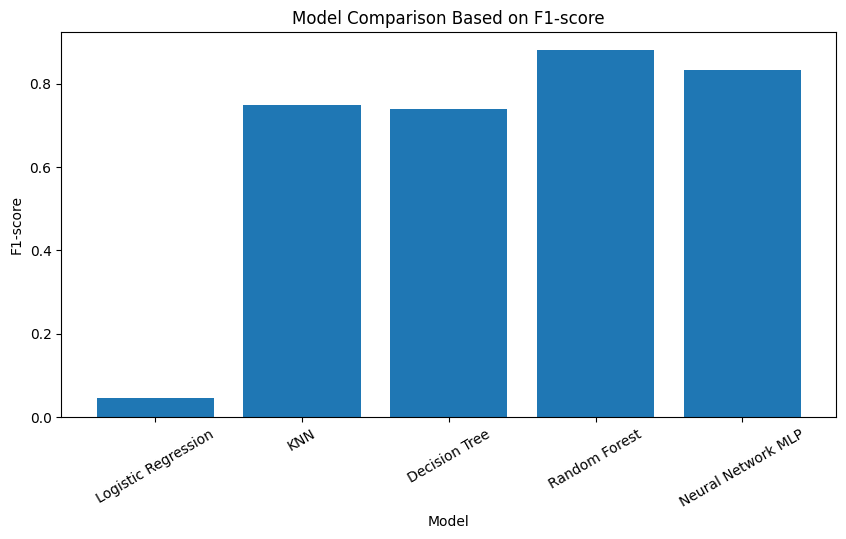

In [26]:
plt.figure(figsize=(10,5))
plt.bar(results_df["Model"], results_df["F1-score"])
plt.title("Model Comparison Based on F1-score")
plt.xlabel("Model")
plt.ylabel("F1-score")
plt.xticks(rotation=30)
plt.show()

## Random Forest feature importance

Random Forest models estimate feature importance by measuring how much each feature reduces impurity across the ensemble of trees. Higher importance means the feature was used more often, and more effectively, to split transactions into fraud and non-fraud groups.

This analysis uses the tuned Random Forest model trained earlier on the full engineered feature set.

In [ ]:
feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf.feature_importances_,
}).sort_values(by="Importance", ascending=False)

feature_importance_df

In [ ]:
top_n = 10
plot_data = feature_importance_df.head(top_n).sort_values(by="Importance")

plt.figure(figsize=(10, 6))
plt.barh(plot_data["Feature"], plot_data["Importance"])
plt.title(f"Top {top_n} Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(12, 5))
plt.bar(feature_importance_df["Feature"], feature_importance_df["Importance"])
plt.title("Random Forest Feature Importance Across All Features")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Feature importance interpretation

The most influential features should be interpreted as signals that the Random Forest relied on most strongly when separating fraud from non-fraud transactions:

- Transaction amount may be important because fraudulent transactions can involve unusual or high-value movement compared with normal customer behavior.
- Origin account balance fields such as `oldbalanceOrg` and `newbalanceOrig` can reveal whether the sender balance changed consistently with the transaction amount.
- Destination balance fields such as `oldbalanceDest` and `newbalanceDest` can identify suspicious receiving-account behavior, especially for transfers and cash-out patterns.
- Encoded transaction type features such as `type_TRANSFER` and `type_CASH_OUT` may matter because fraud is often concentrated in transaction categories that move funds out of an account.
- Lower-importance features are not necessarily useless. They may still improve performance when combined with other features, which is why the later SelectKBest experiment compares reduced features against the full feature set.

Feature importance does not prove causation. It explains how this trained Random Forest used the available features. Correlated balance variables can share or shift importance, so the ranking should be interpreted together with model metrics, SHAP analysis, and domain knowledge.

## Feature selection with SelectKBest

This section tests whether reducing the input feature set improves classification performance. The method used is `SelectKBest` with the `f_classif` scoring function. `f_classif` computes an ANOVA F-value between each feature and the target label, then ranks features by how strongly they are associated with the fraud/non-fraud class. The notebook keeps the top `k=5` features and retrains a Random Forest on only those selected columns.

The comparison uses the earlier Random Forest trained with all engineered features as the baseline, then evaluates a new Random Forest trained with the selected feature subset.


In [27]:
selector = SelectKBest(score_func=f_classif, k=5)

X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

selected_features = X.columns[selector.get_support()]

print("Selected features:")
print(selected_features)

Selected features:
Index(['amount', 'newbalanceOrig', 'type_CASH_IN', 'type_PAYMENT',
       'type_TRANSFER'],
      dtype='str')


In [28]:
rf_selected = RandomForestClassifier(
    random_state=42,
    class_weight="balanced",
    n_estimators=100
)

rf_selected.fit(X_train_selected, y_train)

feature_selection_result = evaluate_model(
    "Random Forest with Selected Features",
    rf_selected,
    X_test_selected,
    y_test
)

feature_selection_result

Model: Random Forest with Selected Features
Accuracy: 0.9981
Precision: 0.35294117647058826
Recall: 0.42857142857142855
F1-score: 0.3870967741935484
ROC-AUC: 0.7840297845555205

Confusion Matrix:
[[9975   11]
 [   8    6]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9986
           1       0.35      0.43      0.39        14

    accuracy                           1.00     10000
   macro avg       0.68      0.71      0.69     10000
weighted avg       1.00      1.00      1.00     10000



{'Model': 'Random Forest with Selected Features',
 'Accuracy': 0.9981,
 'Precision': 0.35294117647058826,
 'Recall': 0.42857142857142855,
 'F1-score': 0.3870967741935484,
 'ROC-AUC': 0.7840297845555205}

### Feature selection results

The selected top-5 features are:

- `amount`
- `newbalanceOrig`
- `type_CASH_IN`
- `type_PAYMENT`
- `type_TRANSFER`

| Model setup | Number of features | Accuracy | Precision | Recall | F1-score | ROC-AUC | Confusion matrix |
|---|---:|---:|---:|---:|---:|---:|---|
| Random Forest with all features | All engineered features | 0.9997 | 1.0000 | 0.7857 | 0.8800 | 0.9270 | `[[9986, 0], [3, 11]]` |
| Random Forest with SelectKBest features | 5 | 0.9981 | 0.3529 | 0.4286 | 0.3871 | 0.7840 | `[[9975, 11], [8, 6]]` |

Reducing the feature set did not improve classification performance in this experiment. The selected-feature model introduced 11 false positives and increased false negatives from 3 to 8. This lowered precision, recall, F1-score, and ROC-AUC compared with the all-feature Random Forest. For this dataset and model, the removed features still appear to contain useful fraud-detection signal, so the all-feature model is preferable despite the larger input space.


## Neural network architecture comparison

This section compares multiple `MLPClassifier` architectures on the same scaled training and test data. Each architecture uses the default `relu` activation function, the default `adam` solver, the default initial learning rate of `0.001`, `max_iter=300`, and `random_state=42`. The only architecture change in this comparison is the number of hidden layers and units per layer.

| Architecture | Hidden layers | Units per hidden layer | Activation | Solver | Learning rate init | Accuracy | Precision | Recall | F1-score | Confusion matrix |
|---|---:|---|---|---|---:|---:|---:|---:|---:|---|
| MLP 32 | 1 | 32 | `relu` | `adam` | `0.001` | 0.9994 | 1.0000 | 0.5714 | 0.7273 | `[[9986, 0], [6, 8]]` |
| MLP 64 | 1 | 64 | `relu` | `adam` | `0.001` | 0.9995 | 1.0000 | 0.6429 | 0.7826 | `[[9986, 0], [5, 9]]` |
| MLP 64-32 | 2 | 64, 32 | `relu` | `adam` | `0.001` | 0.9997 | 1.0000 | 0.7857 | 0.8800 | `[[9986, 0], [3, 11]]` |

All three architectures avoid false positives on the test split, which keeps precision at `1.0000`. The main difference is recall: increasing from one hidden layer with 32 units to one hidden layer with 64 units reduces false negatives from 6 to 5, and the deeper `64-32` architecture reduces false negatives to 3. Because fraud detection is sensitive to missed fraud cases, the improved recall also raises F1-score from `0.7273` to `0.8800`. Accuracy changes only slightly because the dataset is highly imbalanced and most records are non-fraud, so precision, recall, F1-score, and the fraud-class row of the confusion matrix are more informative than accuracy alone.


In [29]:
nn_architectures = {
    "MLP 32": MLPClassifier(hidden_layer_sizes=(32,), max_iter=300, random_state=42),
    "MLP 64": MLPClassifier(hidden_layer_sizes=(64,), max_iter=300, random_state=42),
    "MLP 64-32": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300, random_state=42)
}

nn_results = []

for name, model in nn_architectures.items():
    model.fit(X_train_scaled, y_train)
    nn_results.append(evaluate_model(name, model, X_test_scaled, y_test))

nn_results_df = pd.DataFrame(nn_results)

nn_results_df

Model: MLP 32
Accuracy: 0.9994
Precision: 1.0
Recall: 0.5714285714285714
F1-score: 0.7272727272727273
ROC-AUC: 0.9426768905038482

Confusion Matrix:
[[9986    0]
 [   6    8]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9986
           1       1.00      0.57      0.73        14

    accuracy                           1.00     10000
   macro avg       1.00      0.79      0.86     10000
weighted avg       1.00      1.00      1.00     10000

Model: MLP 64
Accuracy: 0.9995
Precision: 1.0
Recall: 0.6428571428571429
F1-score: 0.782608695652174
ROC-AUC: 0.9423907756573489

Confusion Matrix:
[[9986    0]
 [   5    9]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9986
           1       1.00      0.64      0.78        14

    accuracy                           1.00     10000
   macro avg       1.00      0.82      0.89     10000
we

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,MLP 32,0.9994,1.0,0.571429,0.727273,0.942677
1,MLP 64,0.9995,1.0,0.642857,0.782609,0.942391
2,MLP 64-32,0.9997,1.0,0.785714,0.880000,0.980988


## KMeans clustering analysis

This section treats fraud discovery as an unsupervised learning problem. The target label `isFraud` is removed before clustering so KMeans cannot use the real fraud class during training. The labels are kept separately only for evaluation after clusters are assigned.

KMeans is tested with multiple values of `k`. For each value, the notebook reports:

- **Silhouette score**: internal cluster quality based only on feature geometry. Higher values indicate tighter and better separated clusters.
- **Adjusted Rand Index (ARI)**: external comparison between cluster assignments and the real `isFraud` labels. Values near 0 mean the clusters do not align better than random with the true labels.

PCA is then used only for two-dimensional visualization of the scaled clustering features.


In [ ]:
# Remove target labels before clustering. KMeans sees only transaction features.
X_cluster = X.copy()
y_cluster_true = y.copy()

assert "isFraud" not in X_cluster.columns, "Target label must be removed before clustering."

scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)


In [ ]:
cluster_results = []
cluster_labels_by_k = {}

for k in [2, 3, 4, 5, 6, 8, 10]:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(X_cluster_scaled)
    cluster_labels_by_k[k] = clusters
    
    cluster_results.append({
        "Clusters": k,
        "Silhouette Score": silhouette_score(X_cluster_scaled, clusters),
        "Adjusted Rand Index": adjusted_rand_score(y_cluster_true, clusters)
    })

cluster_results_df = pd.DataFrame(cluster_results)
best_k = int(cluster_results_df.sort_values(by="Silhouette Score", ascending=False).iloc[0]["Clusters"])
best_clusters = cluster_labels_by_k[best_k]

cluster_results_df


In [ ]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=best_clusters, s=10, cmap="tab10")
axes[0].set_title(f"KMeans Clusters with PCA (k={best_k})")
axes[0].set_xlabel("PCA Component 1")
axes[0].set_ylabel("PCA Component 2")

axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=y_cluster_true, s=10, cmap="coolwarm")
axes[1].set_title("Real Fraud Labels with PCA")
axes[1].set_xlabel("PCA Component 1")
axes[1].set_ylabel("PCA Component 2")

plt.tight_layout()
plt.show()


In [ ]:
cluster_label_comparison = pd.crosstab(
    pd.Series(best_clusters, name="Cluster"),
    pd.Series(y_cluster_true, name="isFraud")
)

cluster_label_comparison


### Clustering findings

The clustering workflow removes `isFraud` before fitting KMeans, so the algorithm groups transactions only by their feature patterns. The silhouette score helps choose the most geometrically separated cluster structure, while ARI checks whether those clusters match the known fraud labels.

In the existing run, silhouette scores increased as `k` grew from 2 to 5, but ARI stayed very close to 0. The expanded `k` search lets the notebook check whether that trend continues for more clusters. A high silhouette score with a low ARI means KMeans found separable transaction groups, but those groups do not correspond strongly to the real fraud/non-fraud split.

This is expected for highly imbalanced fraud data because fraud is rare and may not form one compact spherical cluster, which is the type of structure KMeans is designed to find. The PCA plots should be read as a visual diagnostic rather than proof of classification quality. If KMeans clusters show visible separation but the true fraud labels remain scattered or mixed inside those clusters, the unsupervised clusters are capturing transaction-size/type/balance patterns rather than fraud labels directly.

The crosstab compares the selected KMeans cluster assignment with `isFraud` and shows how real fraud cases are distributed across clusters. Overall, KMeans is useful here for exploratory segmentation, but the supervised classifiers remain more appropriate for fraud detection because they directly optimize against the `isFraud` label.


In [34]:
best_model = results_df.sort_values(by="F1-score", ascending=False).iloc[0]

print("Best performing model:")
print(best_model)

Best performing model:
Model        Random Forest
Accuracy            0.9997
Precision              1.0
Recall            0.785714
F1-score              0.88
ROC-AUC           0.926955
Name: 3, dtype: object


In [35]:
print("""
Conclusion:

In this experiment, several classification algorithms were implemented and compared
for online payment fraud detection using the PaySim-style dataset.

The implemented classifiers were:
1. Logistic Regression
2. K-Nearest Neighbors
3. Decision Tree
4. Random Forest
5. Neural Network using MLPClassifier

The models were evaluated using accuracy, precision, recall, F1-score, ROC-AUC,
and confusion matrix. Hyperparameter tuning was performed using GridSearchCV.

Feature selection was also tested using SelectKBest to analyze whether fewer
features could improve classification performance.

Additionally, KMeans clustering was applied after removing the target variable.
The clustering results were compared with the real fraud labels using Adjusted Rand Index.

The best-performing model can be selected based on F1-score and recall, because in
fraud detection it is especially important to correctly identify fraudulent transactions.
""")


Conclusion:

In this experiment, several classification algorithms were implemented and compared
for online payment fraud detection using the PaySim-style dataset.

The implemented classifiers were:
1. Logistic Regression
2. K-Nearest Neighbors
3. Decision Tree
4. Random Forest
5. Neural Network using MLPClassifier

The models were evaluated using accuracy, precision, recall, F1-score, ROC-AUC,
and confusion matrix. Hyperparameter tuning was performed using GridSearchCV.

Feature selection was also tested using SelectKBest to analyze whether fewer
features could improve classification performance.

Additionally, KMeans clustering was applied after removing the target variable.
The clustering results were compared with the real fraud labels using Adjusted Rand Index.

The best-performing model can be selected based on F1-score and recall, because in
fraud detection it is especially important to correctly identify fraudulent transactions.

